# Интерпретируемость моделей: от встроенных важностей до SHAP и LIME с нуля

Методов объяснить предсказание модели много, и они регулярно противоречат друг другу. Здесь я прогоняю основные из них по одним и тем же данным и моделям, чтобы понять, где расхождения принципиальные, а где вызваны неаккуратным применением метода.

Данные — World Happiness Report 2021. Датасет удобен тем, что признаки содержательные и заведомо частично скоррелированы (ВВП, социальная поддержка, ожидаемая продолжительность жизни, свобода выбора, щедрость, восприятие коррупции), а один из них по построению мультиколлинеарен с таргетом — хорошая проверка на то, заметит ли это метод интерпретации.

Разбираются по порядку: коэффициенты линейных моделей и встроенные важности деревьев, ICE, PDP и ALE, permutation importance, occlusion-based важность через сдвиг признака к медиане, затем SHAP и LIME — глобально и локально. ICE и LIME написаны вручную: первый чтобы прогнать модель за пределами обучающего диапазона признаков, второй чтобы посмотреть, насколько коэффициенты локальной модели устойчивы к ширине ядра и числу сэмплов.

Стек: scikit-learn, SHAP, LIME, pyALE.

---


##  **Основные методы оценки важности признаков для ML моделей**

Поработаем с данными о Всемирном отчёте о счастье (World Happiness Report).

## **Подготовительная часть**

In [9]:
pip install shap -qU

Note: you may need to restart the kernel to use updated packages.


In [13]:
pip install -qU pyALE

Note: you may need to restart the kernel to use updated packages.


In [15]:
pip install -qU lime fat-forensics[all]

Note: you may need to restart the kernel to use updated packages.


### **Подготовка данных**

[Датасет](https://github.com/michaelgreenacre/PCA/blob/main/world-happiness-report-2021.csv)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.svm import SVR

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.inspection import partial_dependence, PartialDependenceDisplay
from sklearn.metrics import mean_squared_error

In [3]:
data_to_work = pd.read_csv('world-happiness-report-2021-prep.csv')

data_to_work.head(5)

,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,7.842,10.775,0.954,72.0,0.949,-0.098,0.186,3.253
1,7.620,10.933,0.954,72.7,0.946,0.030,0.179,2.868
2,7.571,11.117,0.942,74.4,0.919,0.025,0.292,2.839
3,7.554,10.878,0.983,73.0,0.955,0.160,0.673,2.967
4,7.464,10.932,0.942,72.4,0.913,0.175,0.338,2.798


### Примечание про столбец Dystopia + residual.


В World Happiness Report Dystopia - это не реальная страна, а техническая точка отсчёта: гипотетическая страна с минимальными значениями по ключевым факторам (GDP, social support, life expectancy, freedom, generosity, corruption). Её вводят как бенчмарк, чтобы вклады факторов в разложении были неотрицательными.

Столбец `Dystopia + residual` - это  разложения: базовый уровень (оценка жизни в Dystopia) плюс остаточная часть, которую шесть факторов не объясняют для конкретной страны (ошибка/невязка модели). Это не социальный индекс, а слагаемое, которое вместе с вкладами 6 факторов даёт итоговый score.

Иначе говоря, в таблицах WHR:
Score ~ (вклады 6 факторов) + (Dystopia + residual).

###

In [8]:
X = data_to_work.drop('Ladder score', axis=1)
y = data_to_work['Ladder score']

Для обучения будем использовать два способа масштабирования - `MinMaxScaler` и `StandardScaler`.

In [11]:
feature_names = list(X.columns)

# Признак для анализа
feature_idx = 1
feature_name = X.columns[feature_idx]

print(f'FEATURE TO ANALYZE: {feature_name}')

FEATURE TO ANALYZE: Social support


In [13]:
# Разделение на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 1
sc_minmax = MinMaxScaler()
X_train_sc_minmax = sc_minmax.fit_transform(X_train)
X_test_sc_minmax = sc_minmax.transform(X_test)

# 2
sc_standard = StandardScaler()
X_train_sc_standard = sc_standard.fit_transform(X_train)
X_test_sc_standard = sc_standard.transform(X_test)

### 1. Обучение моделей и чувствительность к масштабированию
- Обучим 6 моделей:
  -  линейную регрессию (`LinearRegression`) на двух вариантах данных;
  - Lasso регрессию (`Lasso`) на двух вариантах данных;
  - градиентный бустинг (`GradientBoostingRegressor`) на двух вариантах данных;
- Посмотрим на MSE и RMSE моделей.

> Сделаем выводы какие модели чувствительны к масштабу признаков (Lasso), а какие почти инвариантны (LR/деревья), и почему это важно для интерпретации.


**NB:** Для бустингов ограничим глубину до 5.

In [16]:
results = []

models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(alpha=0.08, random_state=888), 
    'Gradient Boosting': GradientBoostingRegressor(max_depth=5, random_state=42)
}

datasets = [
    ('MinMaxScaler', X_train_sc_minmax, X_test_sc_minmax),
    ('StandardScaler', X_train_sc_standard, X_test_sc_standard)
]

for model_name, model in models.items():
    
    for scaler_name, X_tr, X_te in datasets:
        
        model.fit(X_tr, y_train)
        y_pred = model.predict(X_te)
        
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        
        results.append({
            'Model': model_name,
            'Scaler': scaler_name,
            'MSE': round(mse, 4),
            'RMSE': round(rmse, 4)
        })


results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

            Model         Scaler    MSE   RMSE
Linear Regression   MinMaxScaler 0.0000 0.0010
Linear Regression StandardScaler 0.0000 0.0010
            Lasso   MinMaxScaler 0.3405 0.5835
            Lasso StandardScaler 0.0213 0.1459
Gradient Boosting   MinMaxScaler 0.1531 0.3913
Gradient Boosting StandardScaler 0.1531 0.3912


Линейная регрессия и градиентный бустинг инвариантны к масштабу. Хоть масштабирование признаков не оказывает сильного влияния на качество, проводить его необходимо для более справедливого сравнения коэффициентов любой из 6 моделей в будущем.

Для Lasso MinMaxScaler показывает сравнительно большое отклонение, так как он очень чувствителен к выбросам, а StandardScaler центрирует данные и помогает провести отбор признаков лучше. У модели высокая чувствительность к масштабу признаков.

## **Интерпретация по определению**

Воспользуемся встроенными важностями в моделях. Для бустинга — усредненная важность по деревьям, для регрессий — коэффициенты.

### 2. Сравнение коэффициентов при разных scaler'ах
- Построим barplot, визуально оценим и сравним коэффициенты по парам моделей:
  - Модель и `StandardScaler` vs Модель и `MinMaxScaler`

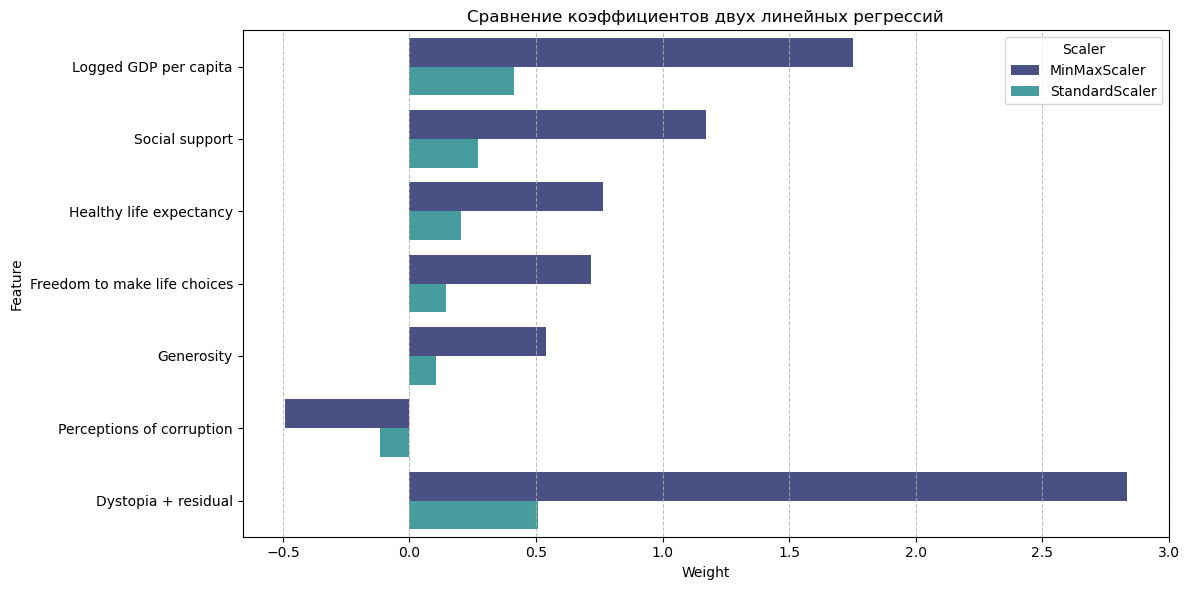

In [20]:
lr_minmax = LinearRegression().fit(X_train_sc_minmax, y_train)
lr_standard = LinearRegression().fit(X_train_sc_standard, y_train)

lr_df = pd.DataFrame({
    'Feature': feature_names,
    'MinMaxScaler': lr_minmax.coef_,
    'StandardScaler': lr_standard.coef_
}).melt(id_vars='Feature', var_name='Scaler', value_name='Weight')

plt.figure(figsize=(12, 6))
sns.barplot(data=lr_df, x='Weight', y='Feature', hue='Scaler', palette='mako')
plt.title('Сравнение коэффициентов двух линейных регрессий', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.8)
plt.tight_layout()
plt.show()

**Вывод:** Значения коэффициентов после использования MinMaxScaler больше, чем после использования StandardScaler, потому что минимаксная нормировка переводит признаки в доли, требуя больших значений коэффициентов для них. Направление влияния признаков сохраняется. Веса для Dystopia + residual фичи такие большие в силу мультиколлинеарности признака по построению.

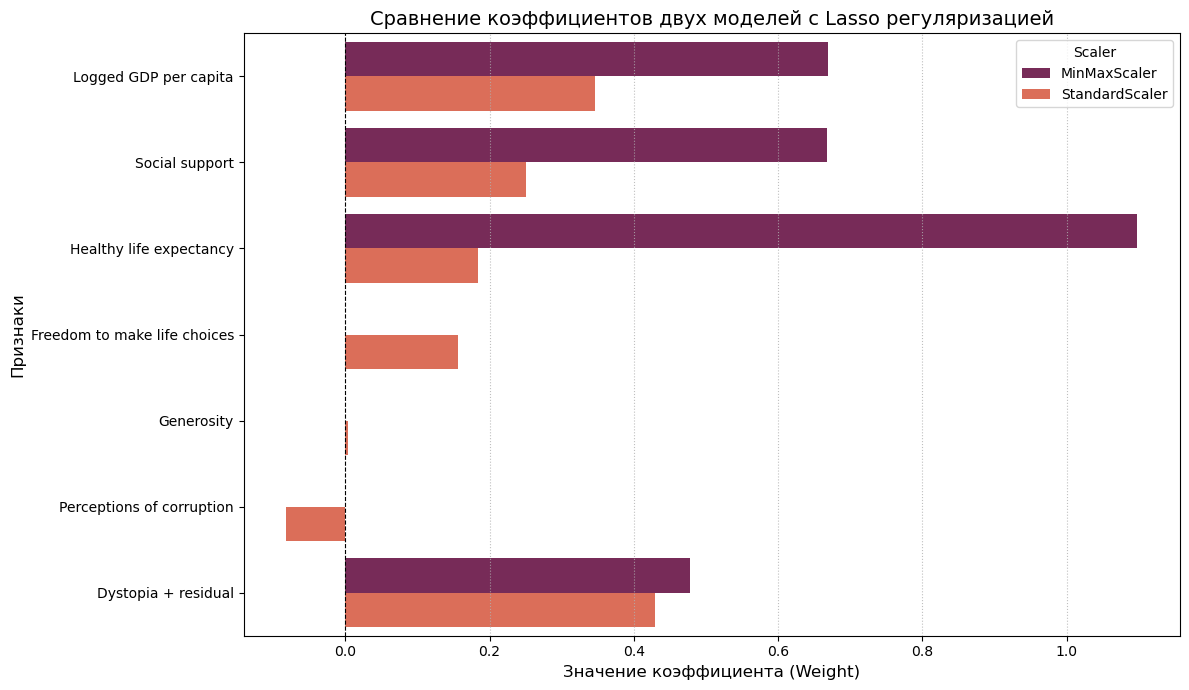

In [23]:
lasso_minmax = Lasso(alpha=0.08, random_state=888).fit(X_train_sc_minmax, y_train)
lasso_standard = Lasso(alpha=0.08, random_state=888).fit(X_train_sc_standard, y_train)

lasso_coeffs_df = pd.DataFrame({
    'Feature': feature_names,
    'MinMaxScaler': lasso_minmax.coef_,
    'StandardScaler': lasso_standard.coef_
}).melt(id_vars='Feature', var_name='Scaler', value_name='Weight')

plt.figure(figsize=(12, 7))
sns.barplot(data=lasso_coeffs_df, x='Weight', y='Feature', hue='Scaler', palette='rocket')

plt.title('Сравнение коэффициентов двух моделей с Lasso регуляризацией', fontsize=14)
plt.xlabel('Значение коэффициента (Weight)', fontsize=12)
plt.ylabel('Признаки', fontsize=12)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--') 
plt.grid(axis='x', linestyle=':', alpha=0.8)
plt.legend(title='Scaler')
plt.tight_layout()
plt.show()

**Вывод:** MinMaxSclaer с Lasso занулил Freedom to make life choice, Generosity, Perceptions of corruption - значит веса для них были слишком большими, признаки неудачно масштабированы, у Lasso высокая к этому чувствительность. Эта регурялизация также помогает слегка побороть мультиколлинеарность, самым важным признаком стал: Healthy life expectancy, а не ввп.

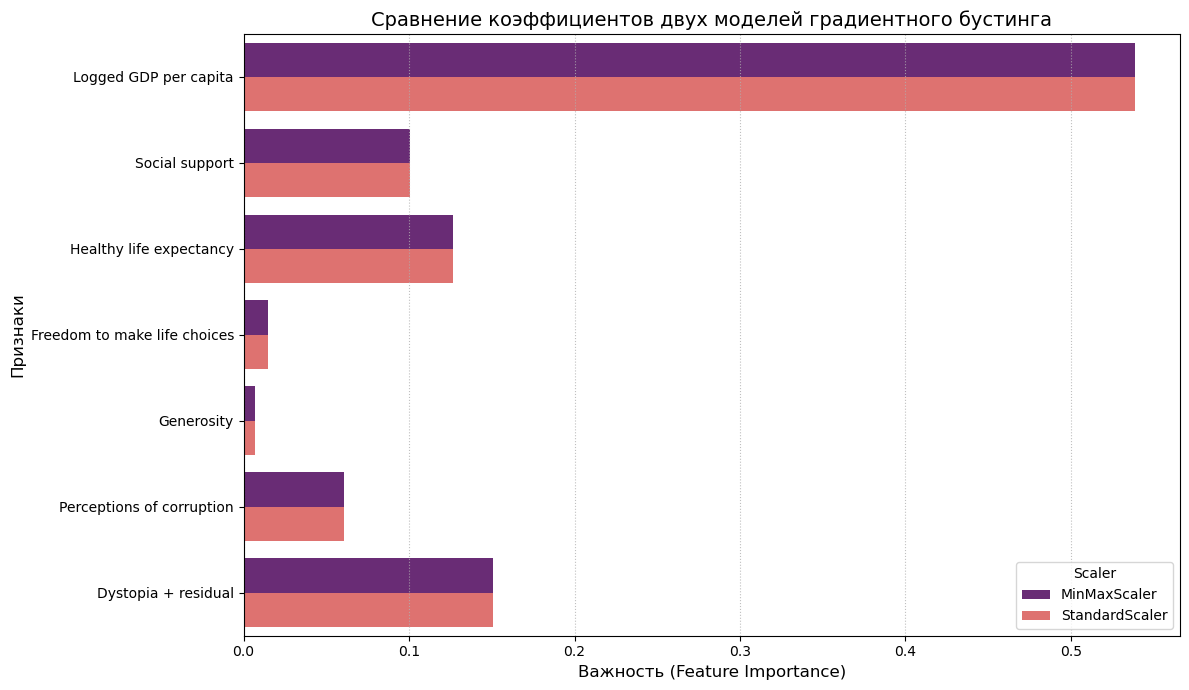

In [26]:
gb_minmax = GradientBoostingRegressor(max_depth=5, random_state=888).fit(X_train_sc_minmax, y_train)
gb_standard = GradientBoostingRegressor(max_depth=5, random_state=888).fit(X_train_sc_standard, y_train)

gb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'MinMaxScaler': gb_minmax.feature_importances_,
    'StandardScaler': gb_standard.feature_importances_
}).melt(id_vars='Feature', var_name='Scaler', value_name='Importance')

plt.figure(figsize=(12, 7))
sns.barplot(data=gb_importance_df, x='Importance', y='Feature', hue='Scaler', palette='magma')

plt.title('Сравнение коэффициентов двух моделей градиентного бустинга', fontsize=14)
plt.xlabel('Важность (Feature Importance)', fontsize=12)
plt.ylabel('Признаки', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.8)
plt.legend(title='Scaler')
plt.tight_layout()
plt.show()

**Вывод:** Наблюдается полная инвариантность к масштабированию признаков. Можно сказать, что с этой точки зрения бустинг самый стабильный.

### 3. Переход между коэффициентами при разных масштабах
Вернемся к графику линейной регрессии. Очевидно, что коэффициенты одной модели связаны с коэффициентами другой. Перейдем от одних к другим: реализуем это в коде, как для свободного члена, так и для самих коэффициентов.

> Идея: коэффициенты линейной модели можно сравнивать как важности только при фиксированном масштабе. Вывод формулы перехода - способ строго показать, что коэффициенты меняются предсказуемо и не являются абсолютной важностью.

In [28]:
std_scale = sc_standard.scale_  
mm_min = sc_minmax.data_min_    
mm_max = sc_minmax.data_max_    
mm_range = mm_max - mm_min      

coef_std = lr_minmax.coef_ * (std_scale / mm_range)

mu = sc_standard.mean_
x_mm_at_std_zero = (mu - mm_min) / mm_range
intercept_std = lr_minmax.predict(x_mm_at_std_zero.reshape(1, -1))[0]

print(f"Calculated Intercept: {intercept_std:.4f}")
print(f"Original Intercept: {lr_standard.intercept_:.4f}")

assert round(intercept_std, 4) == round(lr_standard.intercept_, 4)
assert all(np.round(coef_std, 4) == np.round(lr_standard.coef_, 4))

Calculated Intercept: 5.4848
Original Intercept: 5.4848


## **Plot-based методы**

Теперь оставим для анализа линейную регрессию и бустинг, обученные на Standard scaler.

In [31]:
lr_standard = lr_standard
gb_standard = gb_standard

### **ICE**

**Построение:**

1. Зафиксируем множество $X_{test}$ и некоторый признак $j$. Пусть  $j$ имеет $m$ уникальных значений $[j_1, j_2, ..., j_m]$.

2. Исходный датасет  $X_{test}$ дублируем  $m$ раз: $$X'_1, X'_2, ..., X'_m,$$ так, что для датасета $X'_i$ значение признака $j$ есть $j_i$;

3. На каждом $X'_i$ рассчитываем прогноз модели $f(X'_i)$&

4. На графике строим линии для каждого объекта, показывающие как прогноз (ось $y$) меняется при изменении признака (ось $x$);

ICE реализован в sklearn. Воспользуемся им.

### 4. ICE вручную, за пределами обучающего диапазона

Признаки модели масштабированы определенным образом. Минимум каждого признака равен 0, максимум 1.
- Работая с тем же признаком, изучим его **исходные** минимум и максимум. Создадим искусственный диапазон из 20 точек, равный $[max, 3*max]$.
- На полученном диапазоне построим ICE для обеих моделей. ICE построю собственноручно, без использования sklearn.

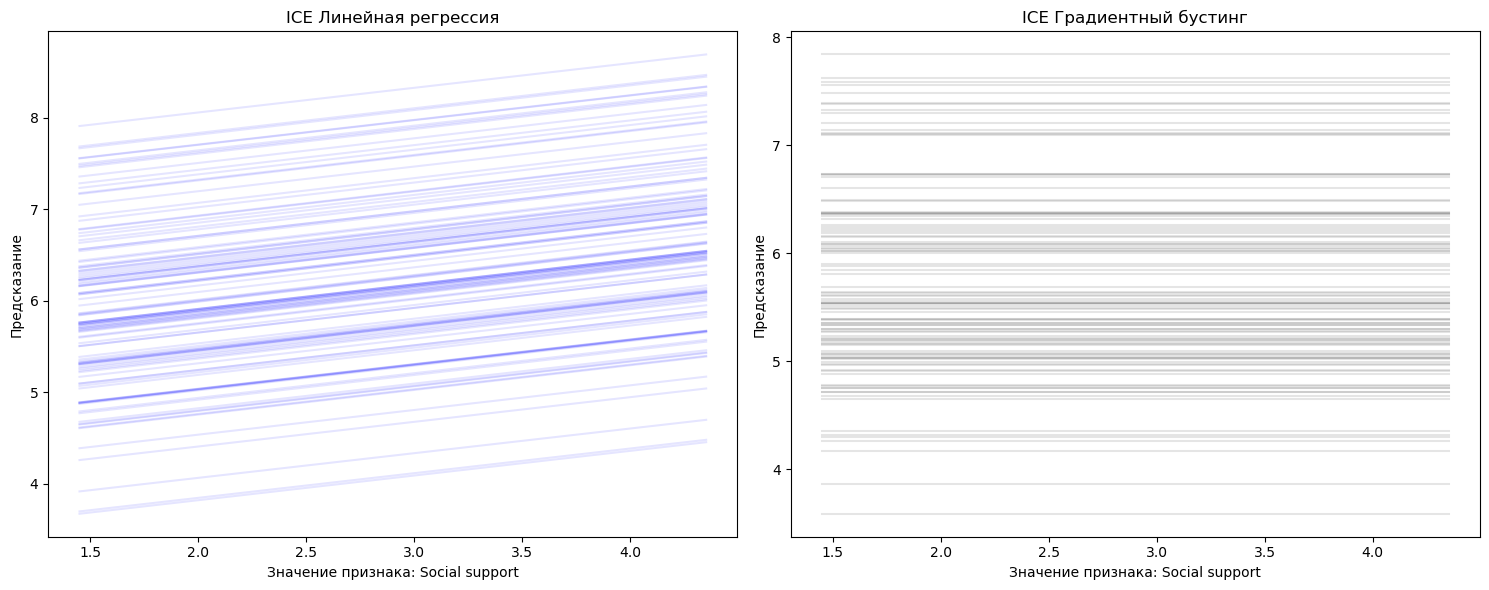

In [34]:
target_feature = 'Social support'
feature_idx = list(feature_names).index(target_feature)

f_min = X_train_sc_standard[:, feature_idx].min()
f_max = X_train_sc_standard[:, feature_idx].max()
custom_range = np.linspace(f_max, 3 * f_max, 20)

def manual_ice(model, X_data, f_idx, grid):
    ice_curves = []
    X_subset = X_data.copy()
    
    for val in grid:
        X_temp = X_subset.copy()
        X_temp[:, f_idx] = val
        preds = model.predict(X_temp)
        ice_curves.append(preds)
    return np.array(ice_curves).T

ice_lr = manual_ice(lr_standard, X_train_sc_standard, feature_idx, custom_range)
ice_gb = manual_ice(gb_standard, X_train_sc_standard, feature_idx, custom_range)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

for i in range(ice_lr.shape[0]):
    ax[0].plot(custom_range, ice_lr[i, :], color='blue', alpha=0.1)
ax[0].set_title(f'ICE Линейная регрессия')
ax[0].set_xlabel(f'Значение признака: {target_feature}')
ax[0].set_ylabel('Предсказание')

for i in range(ice_gb.shape[0]):
    ax[1].plot(custom_range, ice_gb[i, :], color='black', alpha=0.1)
ax[1].set_title(f'ICE Градиентный бустинг')
ax[1].set_xlabel(f'Значение признака: {target_feature}')
ax[1].set_ylabel('Предсказание')

plt.tight_layout()
plt.show()

**Размышления:**

Линейная регрессия характеризуется устремленной в бесконечность линейной экстраполяцией, то есть думает, что при бесконечном увеличении признака "социальная поддержка" прогноз счастья так же будет увеличиваться. Поэтому если признаки выйдут из диапазона для линрега, то модель будет обладать излишним оптимизмом.

В то время как выход из диапазона для градиетного бустинга означает застревание на плато. Модель не совершает предсказаний в непривычной области.

### **PDP**

Теперь посмотрим на усредненное влияние признака.
### 5. Усреднение ICE через PDP

- Усредним ICE по обеим моделям, используя PDP из sklearn.

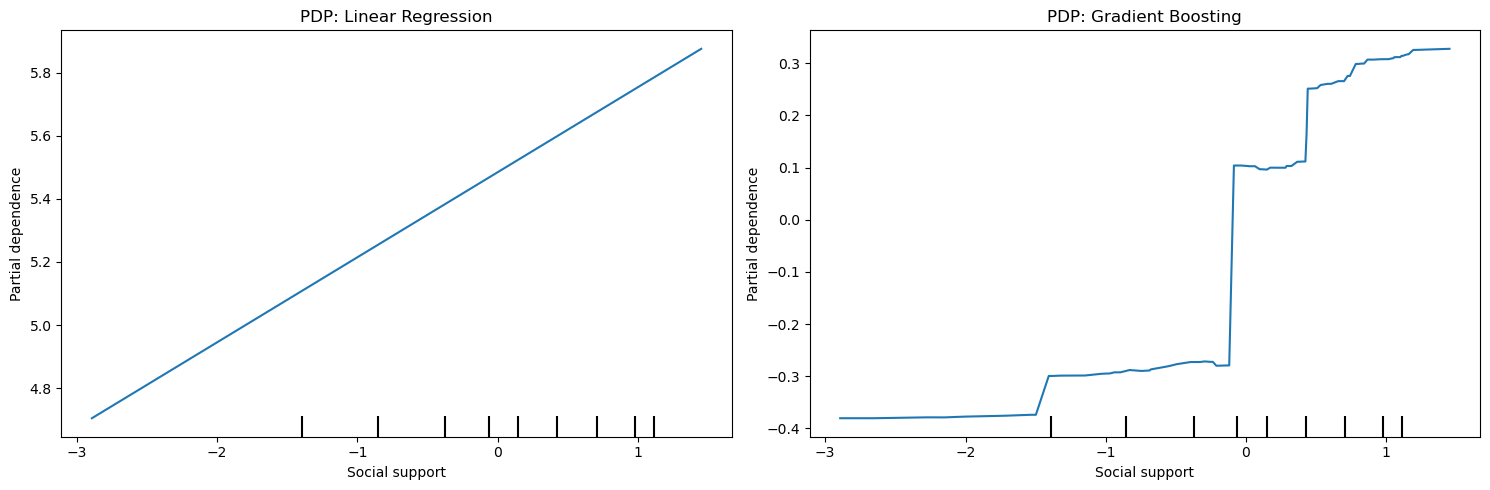

In [38]:
from sklearn.inspection import PartialDependenceDisplay


fig, ax = plt.subplots(1, 2, figsize=(15, 5))

PartialDependenceDisplay.from_estimator(lr_standard, X_train_sc_standard, 
                                        features=[feature_idx], 
                                        feature_names=feature_names, ax=ax[0])
ax[0].set_title('PDP: Linear Regression')

PartialDependenceDisplay.from_estimator(gb_standard, X_train_sc_standard, 
                                        features=[feature_idx], 
                                        feature_names=feature_names, ax=ax[1])
ax[1].set_title('PDP: Gradient Boosting')

plt.tight_layout()
plt.show()

Ранее сделанные выводы подтверждаются, линрег хорош в выявлении общего тренда, но слишком уверен из-за измененного диапазона, а бустинг выходит на плато и отказывается строить прогнозы, что не видел, демонстрируя скачкообразное изменение переменной.

### **Accumulated Local Effects (ALE)**

### 6. Построение ALE с доверительными интервалами

- Построим ALE по обеим моделям, используя pyALE. 
- Подберем размер сетки так, чтобы получить доверительные интервалы. 

> Сетку значений строим в исходных единицах признака, но перед подачей в модель применяем тот же scaler, на котором обучение.

PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


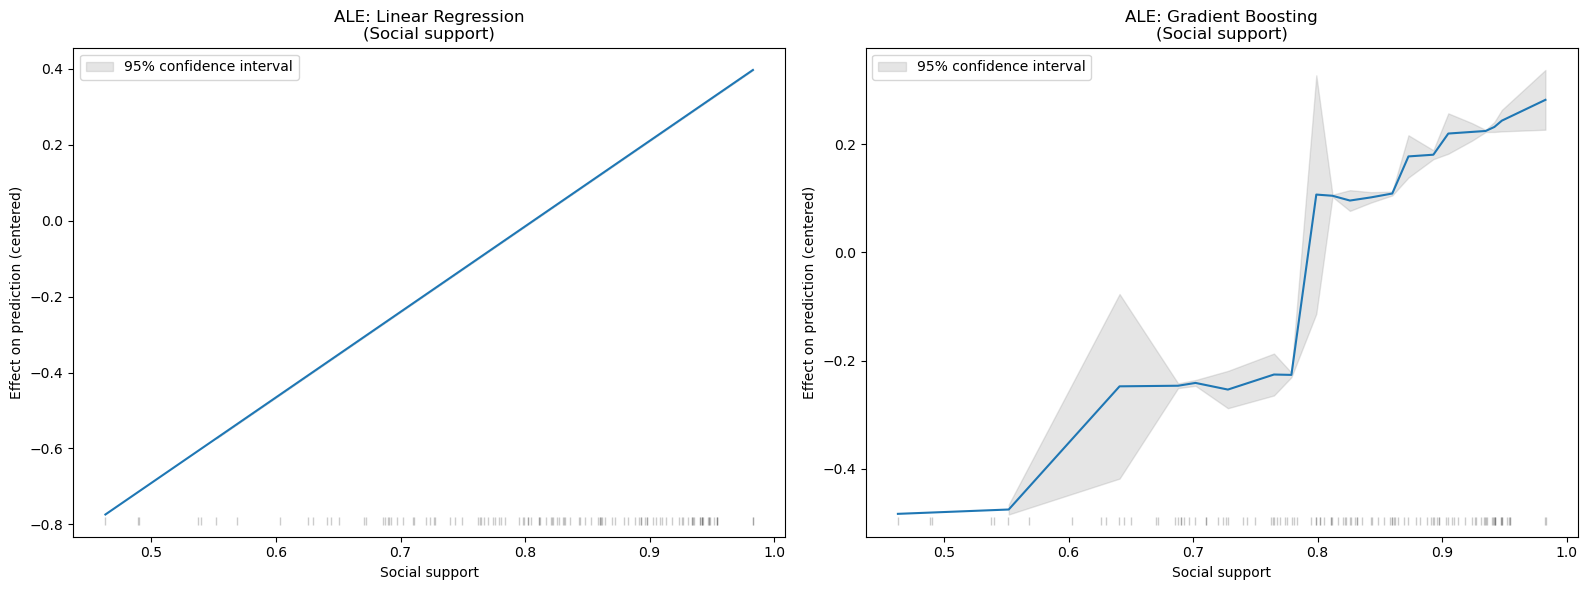

In [42]:
from PyALE import ale

X_train_df = pd.DataFrame(X_train, columns=feature_names)

class ModelWrapper:
    def __init__(self, model, scaler):
        self.model = model
        self.scaler = scaler
    
    def predict(self, X):
        X_scaled = self.scaler.transform(X)
        return self.model.predict(X_scaled)

lr_wrapped = ModelWrapper(lr_standard, sc_standard)
gb_wrapped = ModelWrapper(gb_standard, sc_standard)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))


ale_lr = ale(
    X=X_train_df, 
    model=lr_wrapped, 
    feature=[target_feature], 
    grid_size=20, 
    include_CI=True, 
    plot=True,
    fig=fig,  
    ax=ax1     
)
ax1.set_title(f'ALE: Linear Regression\n({target_feature})')

ale_gb = ale(
    X=X_train_df, 
    model=gb_wrapped, 
    feature=[target_feature], 
    grid_size=20, 
    include_CI=True, 
    plot=True,
    fig=fig,  
    ax=ax2     
)
ax2.set_title(f'ALE: Gradient Boosting\n({target_feature})')

plt.tight_layout()
plt.show()

**Вывод:** после построения ALE доверительный интервал для линейной регрессии отсутствует: она нечувствительна к локальным изменениям в данных, у неё высокое смещение и низкий разброс, то есть модель излишне уверена в этой зависимости. Градиентный бустинг, наоборот, подчёркивает области, где неуверенность в прогнозах высокая, и имеет объёмные неравномерные области неопределённости.

## **Permutation importances**

### 7. Permutation importance и число перестановок

- Построим Permutation importances по обеим моделям, используя sklearn
- Поэкспериментируем с числом перестановок.

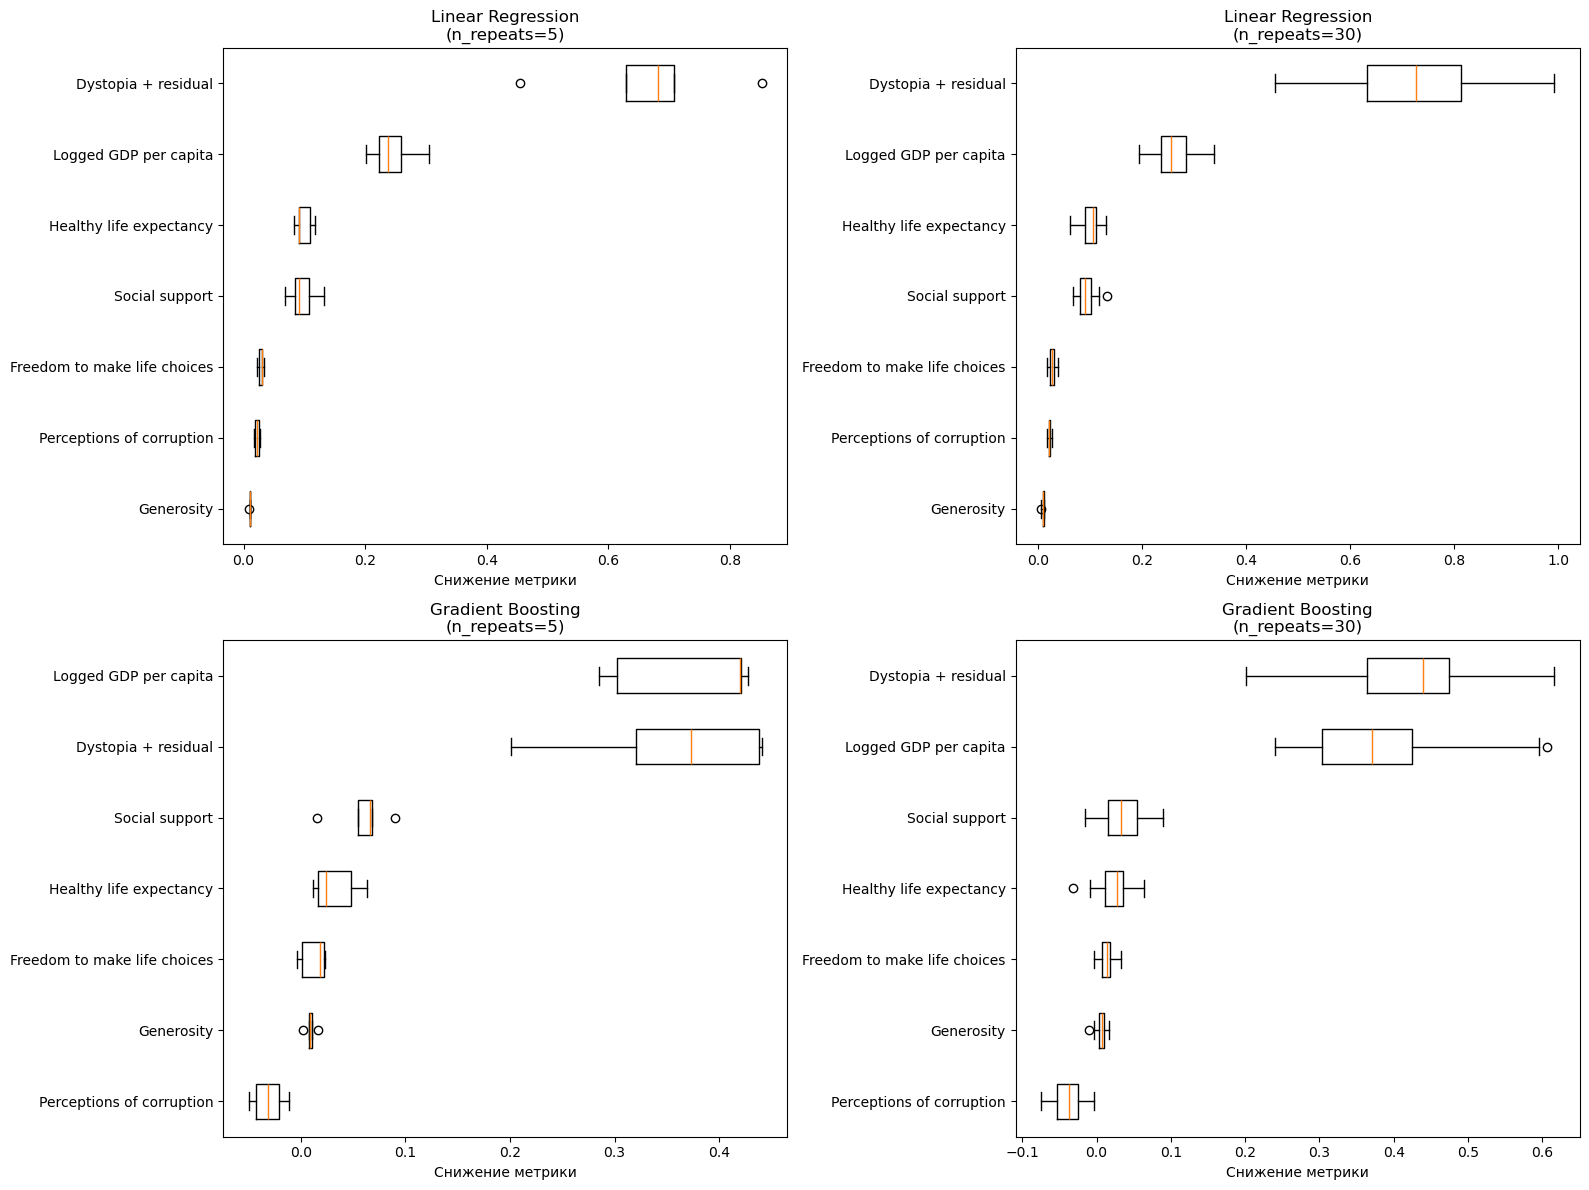

In [46]:
from sklearn.inspection import permutation_importance

repeats_list = [5, 30]
models = {'Linear Regression': lr_standard, 'Gradient Boosting': gb_standard}

fig, axes = plt.subplots(len(models), len(repeats_list), figsize=(16, 12))

for i, (model_name, model) in enumerate(models.items()):
    for j, n_rep in enumerate(repeats_list):
        r = permutation_importance(model, X_test_sc_standard, y_test,
                                   n_repeats=n_rep,
                                   random_state=42,
                                   n_jobs=-1)
        
        sorted_idx = r.importances_mean.argsort()
        
        ax = axes[i, j]
        ax.boxplot(r.importances[sorted_idx].T,
                   vert=False, tick_labels=np.array(feature_names)[sorted_idx])
        
        ax.set_title(f"{model_name}\n(n_repeats={n_rep})")
        ax.set_xlabel("Снижение метрики")

plt.tight_layout()
plt.show()

In [48]:
yo = permutation_importance(gb_standard, X_test_sc_standard, y_test, 
                           n_repeats=30, random_state=42)

importance_df = pd.DataFrame({
    'Importance': yo.importances_mean,
    'Std Deviation': yo.importances_std
}, index=feature_names)


importance_df = importance_df.sort_values(by='Importance', ascending=False)


styled_df = importance_df.style.background_gradient(cmap='YlGnBu', subset=['Importance'])\
            .format("{:.4f}")\
            .set_caption("Permutation Importance: Gradient Boosting with Standard Scaler")\
            .set_table_styles([{'selector': 'caption', 'props': [('color', 'black'), ('font-size', '16px'), ('font-weight', 'bold')]}])

styled_df

,Importance,Std Deviation
Dystopia + residual,0.4250,0.0940
Logged GDP per capita,0.3838,0.0931
Social support,0.0334,0.0269
Healthy life expectancy,0.0251,0.0221
Freedom to make life choices,0.0132,0.0085
Generosity,0.0058,0.0054
Perceptions of corruption,-0.0387,0.0188


**Выводы:** 

Увеличение числа перестановок до 30 зачастую помогает снизить стандартное отклонение для бустинга (ящики уже), делая ранжирование признаков более устойчивым. Также становится ясно, что 'Perceptions of corruption' бесполезен для градиентного бустинга, а признак 'Social Support' он ценит выше линрега.

Линейная регрессия после увеличения числа перестановок показывает увеличение стандартного отклонения, хоть и довольно малое. Эта модель в целом ранжирует лучше, считает, что ВВП и дистопия почти одинаково сильно влияют на ladder score.

### 8. Occlusion-based важность (сдвиг признака к медиане)

Идея перестановочной важности представляет собой частный случай важности при помощи внесения **возмущений** в признак. Возмущения могут быть разных видов:

- внесение случайного шума;
- зануление признака (удобно для изображений);
- сдвиг признака к его базовому значению и оценка траектории изменения прогнозов или качества модели;

Построим оценку на основе сдвига к базовому значению траектории. Примем за базовое значение медиану признака и будем сдвигать исходный признак к медианному с некоторым коэффициентом $\beta$:

$$x_j^{(\beta)}=(1-\beta)x_j+\beta b_j$$

где $b_j$ – медиана признака. Важность будем оценивать как изменение MSE по тест-данным.

1. Реализуем это возмущение. Посмотрим как меняются важности при разных $\beta$?
2. Построим bar-график и сравним ранжирование с **permutation importance**.


Для регрессии эффект очевиден, поэтому эту окклюзию оцениваю только для бустинга.


1. Выберем базовые значения $x_j$ как **медианы по train** (базовые значения обозначим за $b_j$);
2. На тренировочном наборе данных для каждого признака $j$ заменим столбец $x_j$ на $x^{(\beta)}_j=(1-\beta)x_j+\beta b_j$ при разных $\beta$, равных $[0.2, 0.5, 1]$.
3. Посчитаем $\Delta L_j = \text{MSE}(y,\hat y^{(\beta)}_j)-\text{MSE}(y,\hat y)$. Чем больше $\Delta L_j$, тем важнее признак.

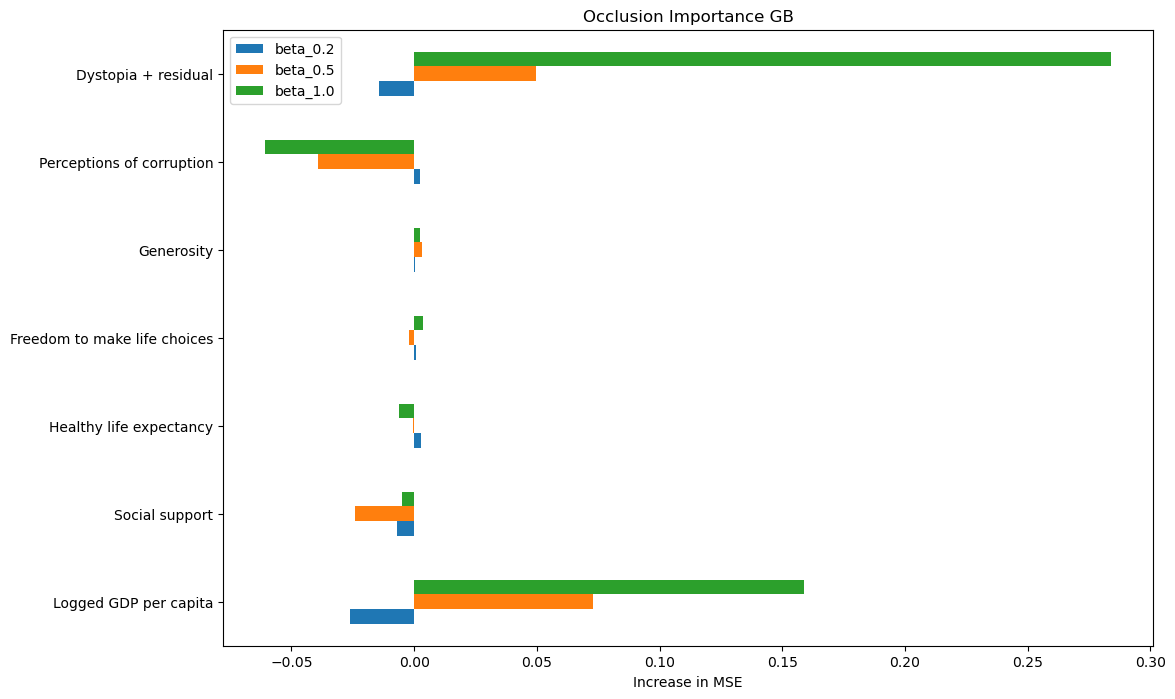

In [52]:
def occlusion_importance(model, X_test, feature_names):
    base_preds = model.predict(X_test)
    base_mse = mean_squared_error(y_test, base_preds)
    
    betas = [0.2, 0.5, 1.0]
    results = {}
    medians = np.median(X_train_sc_standard, axis=0)

    for beta in betas:
        feature_scores = []
        for j in range(len(feature_names)):
            X_perturbed = X_test.copy()
            X_perturbed[:, j] = (1 - beta) * X_test[:, j] + beta * medians[j]
            
            perturbed_preds = model.predict(X_perturbed)
            perturbed_mse = mean_squared_error(y_test, perturbed_preds)
            
            delta_L = perturbed_mse - base_mse
            feature_scores.append(delta_L)
        
        results[f'beta_{beta}'] = feature_scores

    df_occ = pd.DataFrame(results, index=feature_names)
    return df_occ

occ_importance_gb = occlusion_importance(gb_standard, X_test_sc_standard, feature_names)

occ_importance_gb.plot(kind='barh', figsize=(12, 8), title='Occlusion Importance GB')
plt.xlabel('Increase in MSE')
plt.show()

**Вывод:** 

После реализации возмущения важность 'Dystopia + residual' и 'GDP' стала еще явнее. При полном замещении этих признаков соответствующими медианными значения mse модели растет (на 0.28 и 0.16). Однако значения таких признаков, как 'Perceptions of corruption', 'Social Support' и 'GDP' следует заменить их медианными значениями (100% данных, 50% данных и 20% данных, соответсвенно).  

## **SHAP**

Теперь проведем локальный анализ, используя SHAP и LIME. Но для shap также построим глобальные графики.

### 9. Глобальные графики SHAP
- Построим два глобальных графика, используя SHAP. Один из них будет `force`.
- Проанализируем важность признаков в обоих алгоритмах.

**NB:** Для линейного алгоритма использую masker=`shap.maskers.Independent(data=X_train_sc)`. Он имитирует отсутствие признака

Summary Plot (GB):


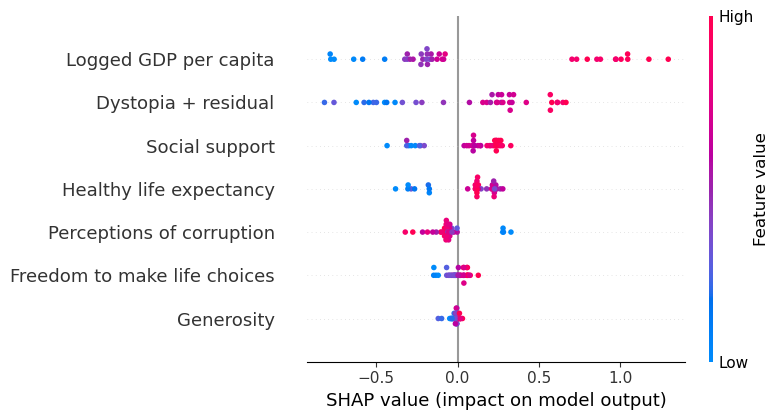

In [56]:
import shap

X_test_df = pd.DataFrame(X_test_sc_standard, columns=feature_names)

masker = shap.maskers.Independent(data=X_train_sc_standard)
explainer_lr = shap.Explainer(lr_standard.predict, masker)
shap_values_lr = explainer_lr(X_test_df)

explainer_gb = shap.TreeExplainer(gb_standard)
shap_values_gb = explainer_gb(X_test_df) 


print("Summary Plot (GB):")
shap.summary_plot(shap_values_gb, X_test_df)

Summary plot: Dystopia + residual и GDP оказывают самое сильное положительное влияниние на прогноз уровня счастья. Social Support также стабильно признается важным признаком. Perceptions of corruption показывает обратную зависимость с shap, что логично, низкий уровень коррупции повышает уровень счастья.

In [59]:
shap.initjs()
print("Force Plot (LR) - первые 50:")

shap.force_plot(
    shap_values_lr.base_values[0], 
    shap_values_lr.values[:50, :], 
    X_test_df.iloc[:50, :]
)

Force Plot (LR) - первые 50:


 **Вывод:** Линейная регрессия также выделяет ранее отмеченные 3 фичи как самые полезные, показывая это расширяющимися красными областями.

## **Локальное объяснение.**

### 10. Локальный SHAP для конкретного объекта
- Построим локальный график с SHAP для объекта с индексом, например, 7 на обеих моделях

SHAP Waterfall: Linear Regression (Объект 7)


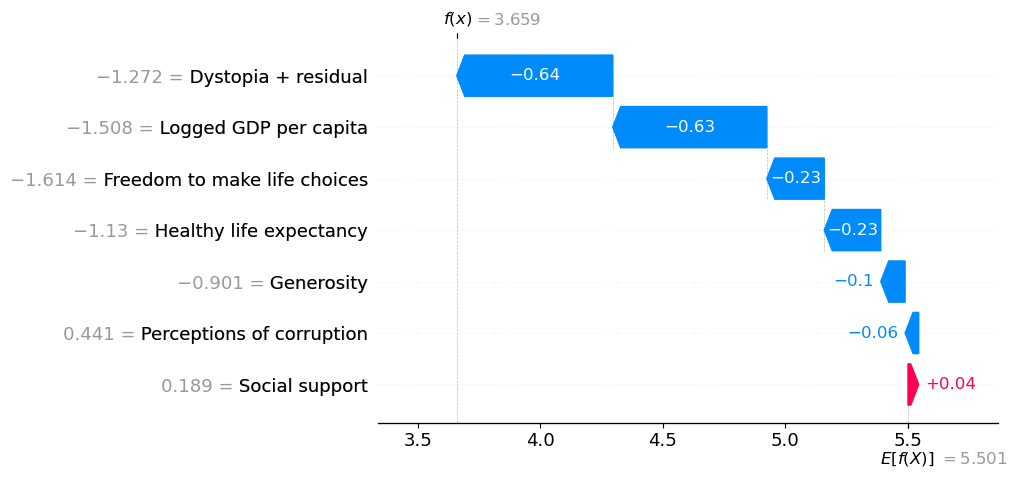

In [62]:
idx = 7

print(f"SHAP Waterfall: Linear Regression (Объект {idx})")
shap.plots.waterfall(shap_values_lr[idx])

SHAP Waterfall: Gradient Boosting (Объект 7)


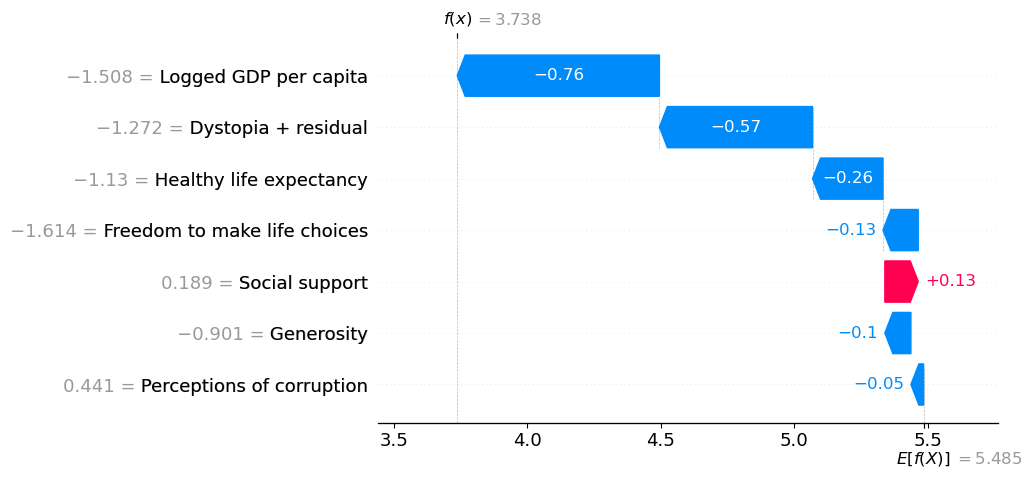

In [64]:
print(f"SHAP Waterfall: Gradient Boosting (Объект {idx})")
shap.plots.waterfall(shap_values_gb[idx])

**Вывод:** Предсказание уровня счастья для объекта с индексом 7 довольно низкое, относительно мат. ожидания. Обе модели выдают похожие прогнозы и считают, что малое значение предикта связано с плохим ввп и Dystopia + residual. Признак Social Support единственный увеличвает уровень счастья объекта 7.

### **Теория: SHAP + categorical**


SHAP разлагает предсказание модели $f(x)$ на базовый уровень $\phi_0=\mathbb E[f(X)]$ и сумму вкладов признаков:

$$
f(x)=\phi_0+\sum_{j=1}^p \phi_j(x).
$$

Значение $\phi_j(x)$ — это «маржинальный вклад» признака $j$ вблизи точки $x$, усреднённый по всем коалициям признаков. Сумма SHAP по признакам всегда совпадает с предсказанием относительно базовой линии — отсюда удобство интерпретации и сравнимость вкладов.

Однако, вопреки этому удобству, SHAP имеет ограничения при работе с категориальными данными в разных кодировках.


1. OneHotEncoding. В этом случае каждому столбцу присвается свое значение Шепли. Общий вклад здесь — всегда **сумма** dummy-столбцов.
2. В CatBoost используется особый способ категориального разбиения, который (при использовании) фактически создаёт новые признаки для разбиения, отсутствующие в исходном наборе входных признаков. Эти признаки позволяют разбивать целые группы категорий тем или иным образом. Поддержка таких типов деревьев пока не реализована в SHAP, но можно использовать в CatBoost — встроенные [ShapValues](https://catboost.ai/docs/en/concepts/shap-values).
3. При других типах кодировок важно проверять отсутствие утечки.



## **LIME**

### 11. LIME для того же объекта, сравнение с SHAP
- Построим локальный график с LIME для объекта с индексом 7 на обеих моделях. Сравним графики с SHAP. Ядро такое использую — `kernel_width=np.sqrt(len(feature_names)) * 0.75`

LIME Explanation: Linear Regression (Объект 7)


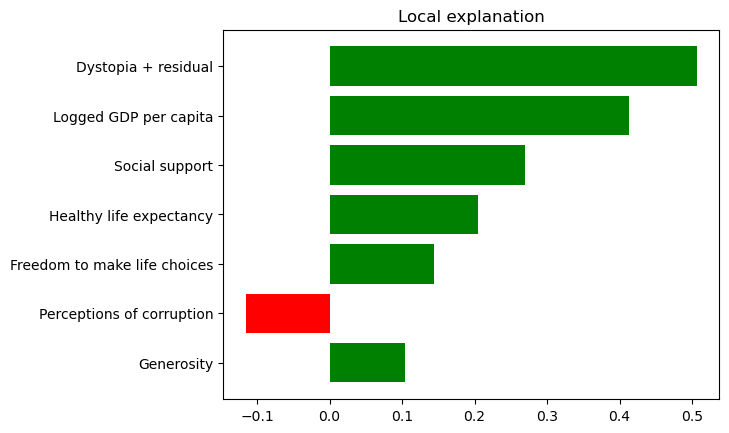

In [69]:
from lime.lime_tabular import LimeTabularExplainer

idx = 7
kernel_width_val = np.sqrt(len(feature_names)) * 0.75

explainer_lime = LimeTabularExplainer(
    training_data=X_train_sc_standard,
    feature_names=feature_names,
    mode='regression',
    kernel_width=kernel_width_val,
    random_state=42,
    discretize_continuous=False 
)

instance_7 = X_test_sc_standard[idx]

print(f"LIME Explanation: Linear Regression (Объект {idx})")
exp_lr = explainer_lime.explain_instance(
    instance_7, 
    lr_standard.predict
)
exp_lr.as_pyplot_figure()
plt.show()

LIME Explanation: Gradient Boosting (Объект 7)


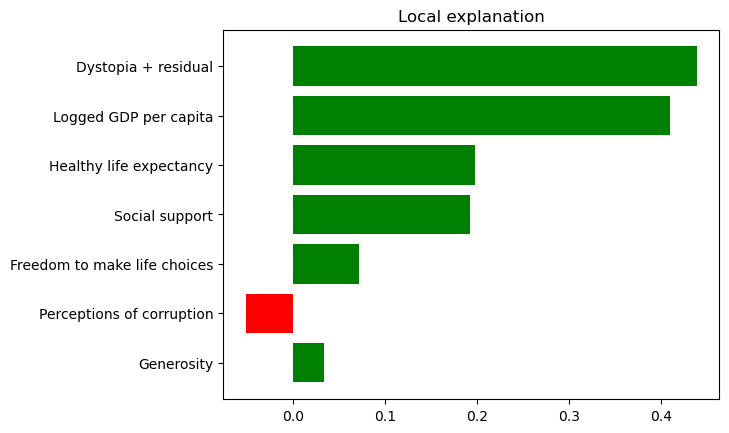

In [71]:
print(f"LIME Explanation: Gradient Boosting (Объект {idx})")
exp_gb = explainer_lime.explain_instance(
    instance_7, 
    gb_standard.predict
)
exp_gb.as_pyplot_figure()
plt.show()

**Вывод:** Иерархия признаков в lime похожа на shap, но dystopia + residual - все же становится самым важным признаком для обоих моделей по Lime.  

### 12. Собственная реализация LIME

Теперь сделаем LIME собственноручно. Реализация будет:

- Принимать на вход точку `x0`
- Вокруг этой точки данных сэмплировать окрестность заданного размера `n`
- На данных из этой окрестности получать прогнозы объясняемой модели (учитывать веса объектов, используя ядро)
- Обучать LIME модель в виде стандартной линейной регрессии
- Возвращать коэффициенты локальной модели


Оценим устойчивость.

**Полезно посмотреть [`fatf`](https://github.com/fat-forensics/fat-forensics)**

**Свой LIME тестируется только для бустинга.**

In [75]:
from sklearn.metrics import pairwise_distances

def my_custom_lime(model, x0, n_samples=1000, kernel_width=None):
    
    n_features = x0.shape[0]
    
    if kernel_width is None:
        kernel_width = np.sqrt(n_features) * 0.75
        
    neighborhood = np.random.normal(loc=x0, scale=1.0, size=(n_samples, n_features))
    
    # черный ящик
    neighborhood_preds = model.predict(neighborhood)
    
    distances = pairwise_distances(neighborhood, x0.reshape(1, -1)).flatten()
    
    # экспоненциальное ядро
    weights = np.sqrt(np.exp(-(distances**2) / (kernel_width**2)))
    
    local_model = LinearRegression()
    local_model.fit(neighborhood, neighborhood_preds, sample_weight=weights)
    
    return local_model.coef_

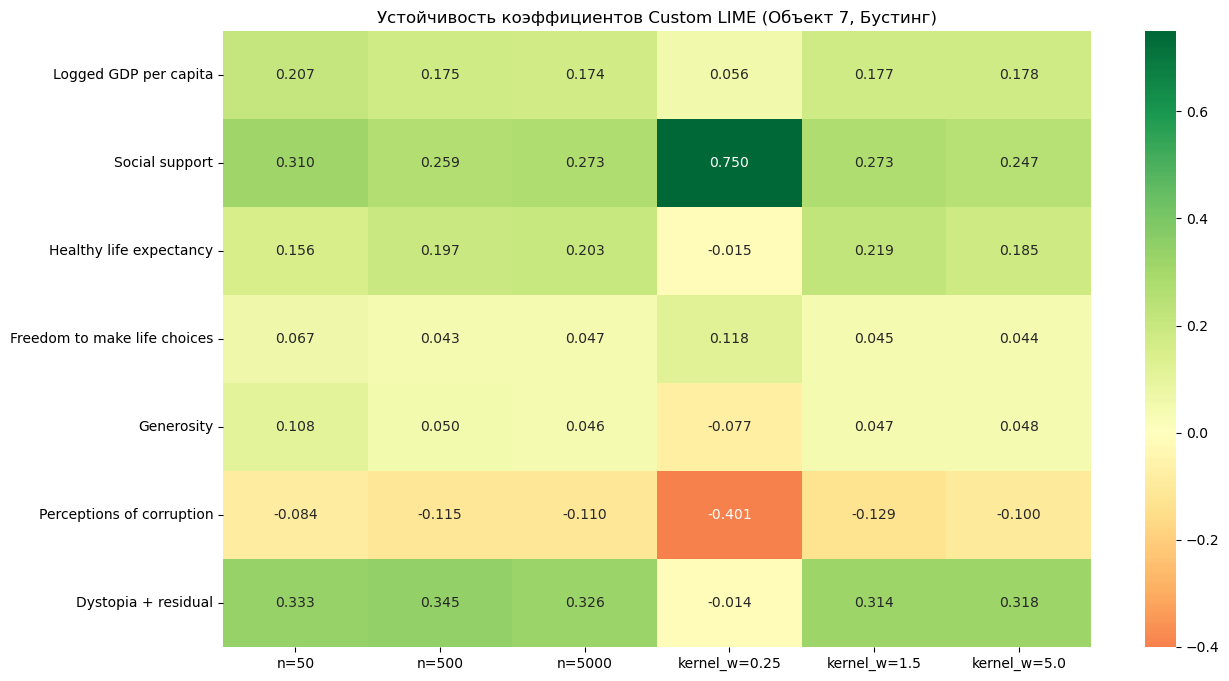

In [77]:
x0_test = X_test_sc_standard[7]

n_variants = [50, 500, 5000]
n_results = {}

for n in n_variants:
    seeds = [1, 42, 888]
    tmp_coefs = []
    for s in seeds:
        np.random.seed(s)
        tmp_coefs.append(my_custom_lime(gb_standard, x0_test, n_samples=n))
    n_results[f'n={n}'] = np.mean(tmp_coefs, axis=0)

widths = [0.25, 1.5, 5.0]
w_results = {}
for w in widths:
    w_results[f'kernel_w={w}'] = my_custom_lime(gb_standard, x0_test, n_samples=5000, kernel_width=w)

stability_df = pd.DataFrame({**n_results, **w_results}, index=feature_names)

plt.figure(figsize=(14, 8))
sns.heatmap(stability_df, annot=True, cmap='RdYlGn', center=0, fmt=".3f")
plt.title("Устойчивость коэффициентов Custom LIME (Объект 7, Бустинг)")
plt.show()

 **Вывод:** 
 
 Увеличение количества сгенерированных точек положительно влияет на стабильность коэффициентов.

 При узком ядре (=0.25) признак Social Support получает очень высокий вес, а значимость ранее самых ползеных признаков падает до нуля. Следовательно, при таком ядре модель переобучается. То есть, увеличение ширины ядра делает интерпретацию коэффциентов более устойчивой.

 Моя реализация похожа на ранее построенные иные модели, довольно устойчива при адекватных значениях гиперпараметров.


---

## Выводы

Коэффициенты линейных моделей нельзя сравнивать между собой, не зафиксировав масштаб признаков. Lasso к этому особенно чувствителен: при неудачном масштабировании он занулил Freedom to make life choices, Generosity и Perceptions of corruption целиком. Формула перехода между MinMax и Standard выведена в работе — она показывает, что коэффициенты меняются предсказуемо и абсолютной важностью не являются.

За пределами обучающего диапазона линейная модель и бустинг расходятся принципиально: первая продолжает экстраполировать с прежней уверенностью, второй выходит на плато и отказывается предсказывать то, чего не видел. Для инференса на данных, выходящих за обучающее распределение, разница критическая, и это видно именно на ручном ICE, а не на встроенном.

SHAP и LIME сходятся в топе признаков, но расходятся в деталях и заметно зависят от гиперпараметров — ширины ядра у LIME, типа маскера у SHAP. При узком ядре (0.25) моя реализация LIME начинала переобучаться под окрестность и раздувала вес одного признака до неадекватного. Вывод простой: ни один метод объяснения не стоит брать как единственный источник истины.

Отдельно стоит помнить про ограничения SHAP на категориальных признаках — при one-hot вклад размазывается по dummy-столбцам, а особый тип категориальных сплитов CatBoost SHAP пока не поддерживает и требует встроенных ShapValues. Связку «модель + метод интерпретации» лучше проверять заранее.
